In [ ]:
import pandas as pd
try:
    df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The CSV file was not found in the current directory.")


Dataset loaded successfully!


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


---Missing Values Per Column---
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Cleaned Dataset Shape: (4546, 4)

---Correlated Matrix with Sales---
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


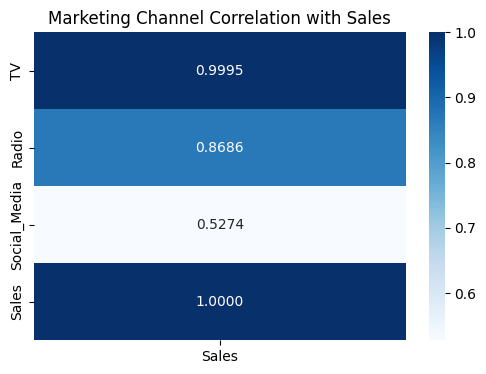

In [3]:
print("---Missing Values Per Column---")
print(df.isnull().sum())
df_clean = df.dropna()
print(f"\nCleaned Dataset Shape: {df_clean.shape}")
print("\n---Correlated Matrix with Sales---")
correlation_matrix = df_clean.corr(numeric_only=True)
print(correlation_matrix['Sales'].sort_values(ascending=False))
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix[['Sales']], annot=True,cmap="Blues", fmt=".4f")
plt.title("Marketing Channel Correlation with Sales")
plt.show()




In [4]:

import statsmodels.api as sm
X = df_clean[['TV']]
y = df_clean['Sales']
X_with_constant = sm.add_constant(X)
model = sm.OLS(y,X_with_constant).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:26:09   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

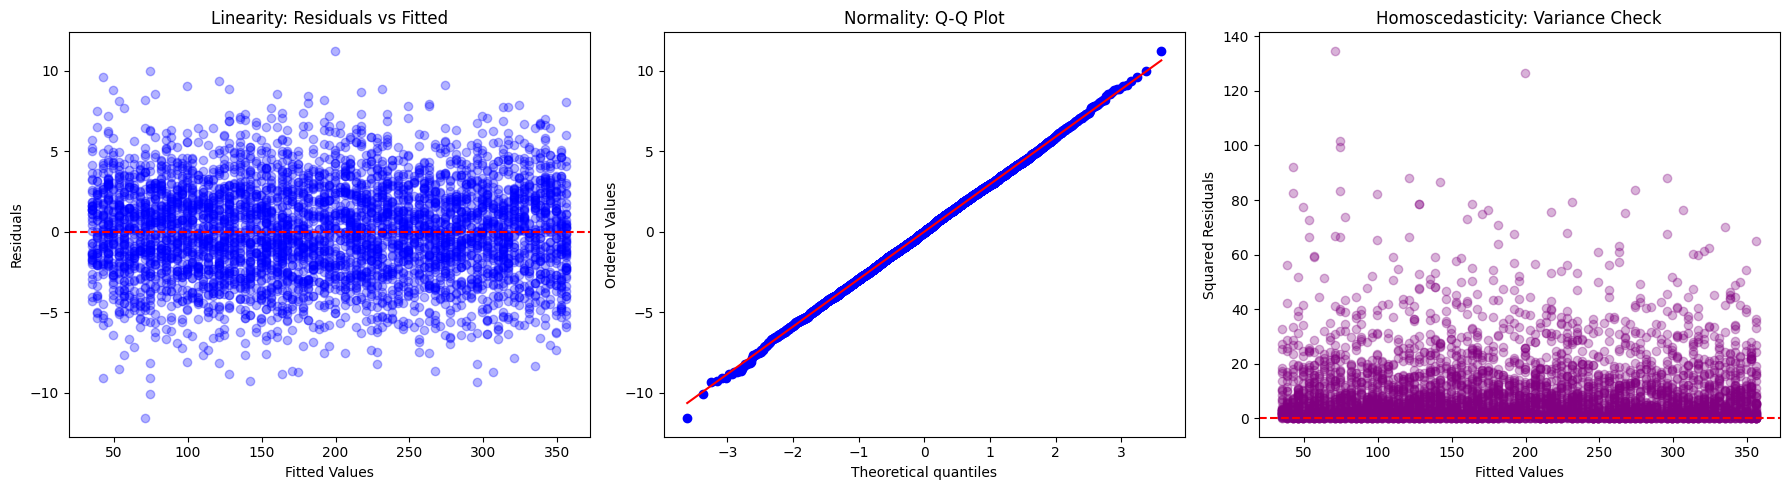

In [5]:
import matplotlib.pyplot as plt
import scipy.stats as stats
fitted_values = model.fittedvalues
residuals = model.resid
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].scatter(fitted_values, residuals, alpha=0.3, color='blue')
axes[0].axhline(0,color='red', linestyle='--')
axes[0].set_title('Linearity: Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Normality: Q-Q Plot')
axes[2].scatter(fitted_values, residuals**2, alpha=0.3, color='purple')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Homoscedasticity: Variance Check')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Squared Residuals')
plt.tight_layout()
plt.show()


## Final Project Evaluation & Strategic Insights
### 1. Model Diagnostics & Assumptions Verification
* **Linearity Verified:** The Residuals vs Fitted plot shows a random, symetric cloud of paints centered around zero, confirming a linear relaionship.
* **Normality Verified:** The Q-Q plot exhibits data points tightly aligned withthe 45-degree reference line, proving normally distributed errors.
* **Homoscedasticity Verified:** The variance plot shows a constant vertical spread from left to right, confirming uniform error variance.
### 2. Business Insights & ROI Multiplier
* **predictive power($R^2 = 0.999$):**TV marketing spend explains 99.9% of the variance in sales.This indicates an incredibly reliable and robust predictive model.
* **The ROI Factor ($\beta_{TV} = 3.5615$):** For every single doller($1.00) invested in TV advertising, Sales revenue increase by **$3.56**.
* **Statistical Significance ($p <0.001$):** The p-value for the TV variableis 0.000, indicating absolute certainty that this trend is not a random coincidence.
### 3. Final Budget Allocation Recommendation
Based on our explanatory data analysis and OLS regression metrics, **TV advertising is the clear winner**. It drastically outperforms Radio, and Social Media.We reccommend allocating the majority of the marketing capital toward TV advertising to scale sales predictably and maximize overall business ROI.